In [1]:
from langgraph.graph import StateGraph , START,END
from langchain_openai import ChatOpenAI
from dotenv import  load_dotenv
from typing import  TypedDict ,Literal

c:\Users\KIIT01\Desktop\LLM\LangGraph\LLM_workflow\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

model = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    temperature=0.3,
)

In [3]:
class quadratic_state(TypedDict):
    a:int
    b:int
    c:int
    d:float
    equation:str
    result:str


In [4]:
def show_equation(state:quadratic_state)->quadratic_state:
    equation=f"{state['a']}x^2 + {state['b']}X +{state['c']}"
    return {'equation':equation}

In [5]:
def cal_discriminant(state:quadratic_state):
    d=state['b']**2-(4*state['a']*state['c'])
    return {'d':d}
    

In [6]:
def real_root(state:quadratic_state):
    root1=(-state['b']+state['d']**0.5)/(2*state['a'])
    root2=(-state['b']-state['d']**0.5)/(2*state['a'])
    result=f"the roots are {root1} and {root2}"

    return {'result':result}
    

In [7]:
def repeated_root(state:quadratic_state):
    root=(-state['b'])/(2*state['a'])
   
    result=f"the repeated root is {root}"

    return {'result':result}
    

In [8]:
def no_real_root(state:quadratic_state):
   
    result=f"No real roots"

    return {'result':result}
    

In [9]:
def check_condition(state:quadratic_state)->Literal['real_root','repeated_root','no_real_root']:
    if state['d']>0:
        return 'real_root'
    elif state['d']==0:
        return 'repeated_root'
    else:
        return 'no_real_root'
        

In [10]:
graph=StateGraph(quadratic_state)

graph.add_node('show_equation',show_equation)
graph.add_node('cal_discriminant',cal_discriminant)
graph.add_node('real_root',real_root)
graph.add_node('repeated_root',repeated_root)
graph.add_node('no_real_root',no_real_root)

#define edges

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','cal_discriminant')
graph.add_conditional_edges('cal_discriminant',check_condition)
graph.add_edge('real_root',END)
graph.add_edge('repeated_root',END)
graph.add_edge('no_real_root',END)




#compile
workflow=graph.compile()

In [16]:
initial_state={'a':2,'b':4,'c':2}
final_state=workflow.invoke(initial_state)

In [17]:
final_state['equation']

'2x^2 + 4X +2'

In [18]:
final_state['d']

0

In [19]:
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'd': 0,
 'equation': '2x^2 + 4X +2',
 'result': 'the repeated root is -1.0'}

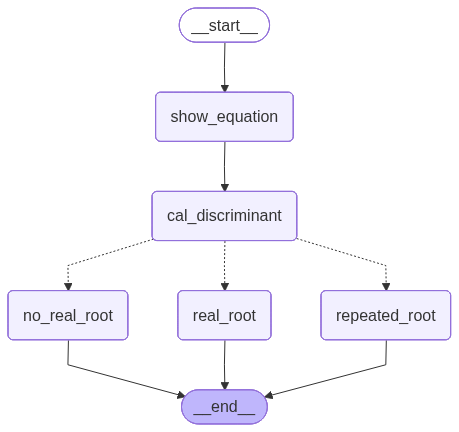

In [15]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())